# 📊 Website Traffic Analysis — Alfido Tech Internship
**Dataset:** [Kaggle – bhanupratapbiswas/website-traffic-analysis](https://www.kaggle.com/datasets/bhanupratapbiswas/website-traffic-analysis)  
**Tool:** Python · pandas · matplotlib · seaborn  
**Period:** August 19 – 25, 2021  
**Task:** Parse & clean data · Compute metrics · Visualize · Recommend optimizations

---

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Notebook display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:,.2f}'.format)
%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'DejaVu Sans',
})

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 2. Load & Preview Dataset

In [2]:
df = pd.read_excel('traffic.xlsx', parse_dates=['date'])

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
df.head(10)

Shape: 226,278 rows × 9 columns
Date range: 2021-08-19 → 2021-08-25


,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores MÃ¡s,No Llores MÃ¡s,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,MalÃ©,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
5,click,2021-08-21,United States,Los Angeles,KenTheMan,I'm Perfect,I'm Perfect,US39N2102090,190c7170-4044-4c97-9709-926917155b02
6,click,2021-08-21,Sierra Leone,Unknown,Coi Leray,No More Parties,No More Parties,USUM72100947,51a9a818-40d2-432d-b48a-9dcff61c6278
7,click,2021-08-21,United Kingdom,Stockport,"Trippie Redd, Lil Uzi Vert",Holy Smokes (feat. Lil Uzi Vert),Holy Smokes,QZJ842001118,4a44b83e-9563-4891-af3f-36fa37421db6
8,click,2021-08-21,United States,Pflugerville,Billie Eilish,Happier Than Ever,Happier Than Ever,USUM72105936,d58a7ad8-f1f7-43c7-90fc-02906b703089
9,click,2021-08-21,France,Unknown,"DMNDS, Strange Fruits Music, Fallen Roses, Luj...",Calabria (feat. Lujavo & Nito-Onna),Calabria (feat. Lujavo & Nito-Onna),GBSMU9833211,681d888a-59ce-4acb-b7c5-95dab0c063d9


## 3. Data Types & Basic Info

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   event    226278 non-null  str           
 1   date     226278 non-null  datetime64[us]
 2   country  226267 non-null  str           
 3   city     226267 non-null  str           
 4   artist   226241 non-null  object        
 5   album    226271 non-null  object        
 6   track    226273 non-null  object        
 7   isrc     219157 non-null  str           
 8   linkid   226278 non-null  str           
dtypes: datetime64[us](1), object(3), str(5)
memory usage: 15.5+ MB


## 4. Summary Statistics

In [4]:
# Categorical summary
df.describe(include='all')

,event,date,country,city,artist,album,track,isrc,linkid
count,226278,226278,226267,226267,226241,226271,226273,219157,226278
unique,3,NaN,211,11993,2419,3252,3562,709,3839
top,pageview,NaN,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
freq,142015,NaN,47334,22791,40841,40841,40841,40841,40841
mean,NaN,2021-08-21 21:04:31.768355,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,2021-08-19 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2021-08-20 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,2021-08-22 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,2021-08-24 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,2021-08-25 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 4a. Per-column value counts (mode, unique, top)

In [5]:
summary = pd.DataFrame({
    'dtype':   df.dtypes,
    'non_null': df.count(),
    'missing':  df.isnull().sum(),
    'missing_%': (df.isnull().sum() / len(df) * 100).round(3),
    'unique':   df.nunique(),
    'top_value': [df[c].mode()[0] if df[c].notna().any() else 'N/A' for c in df.columns],
    'top_freq':  [df[c].value_counts().iloc[0] if df[c].notna().any() else 0 for c in df.columns],
})
summary

,dtype,non_null,missing,missing_%,unique,top_value,top_freq
event,str,226278,0,0.00,3,pageview,142015
date,datetime64[us],226278,0,0.00,7,2021-08-19 00:00:00,35361
country,str,226267,11,0.01,211,Saudi Arabia,47334
city,str,226267,11,0.01,11993,Jeddah,22791
artist,object,226241,37,0.02,2419,Tesher,40841
album,object,226271,7,0.00,3252,Jalebi Baby,40841
track,object,226273,5,0.00,3562,Jalebi Baby,40841
isrc,str,219157,7121,3.15,709,QZNWQ2070741,40841
linkid,str,226278,0,0.00,3839,2d896d31-97b6-4869-967b-1c5fb9cd4bb8,40841


## 5. Data Cleaning

In [6]:
df_clean = df.copy()

# Fill missing country/city with 'Unknown'
df_clean['country'].fillna('Unknown', inplace=True)
df_clean['city'].fillna('Unknown', inplace=True)

# Extract date parts for analysis
df_clean['day']      = df_clean['date'].dt.date
df_clean['weekday']  = df_clean['date'].dt.day_name()
df_clean['day_num']  = df_clean['date'].dt.dayofweek

print("Missing values after cleaning:")
print(df_clean[['event','country','city','artist','track']].isnull().sum())
print(f"\n✅ Dataset cleaned — {len(df_clean):,} rows retained")

Missing values after cleaning:
event       0
country    11
city       11
artist     37
track       5
dtype: int64

✅ Dataset cleaned — 226,278 rows retained


## 6. Key Metrics Computation

In [7]:
total      = len(df_clean)
pageviews  = df_clean[df_clean['event'] == 'pageview'].shape[0]
clicks     = df_clean[df_clean['event'] == 'click'].shape[0]
previews   = df_clean[df_clean['event'] == 'preview'].shape[0]
ctr        = clicks / pageviews * 100
countries  = df_clean['country'].nunique()
artists    = df_clean['artist'].nunique()
tracks     = df_clean['track'].nunique()

print("=" * 45)
print(f"  Total Events       : {total:>10,}")
print(f"  Pageviews          : {pageviews:>10,}  ({pageviews/total*100:.1f}%)")
print(f"  Clicks             : {clicks:>10,}  ({clicks/total*100:.1f}%)")
print(f"  Previews           : {previews:>10,}  ({previews/total*100:.1f}%)")
print(f"  Click-Through Rate : {ctr:>9.1f}%")
print(f"  Countries          : {countries:>10,}")
print(f"  Unique Artists     : {artists:>10,}")
print(f"  Unique Tracks      : {tracks:>10,}")
print("=" * 45)

  Total Events       :    226,278
  Pageviews          :    142,015  (62.8%)
  Clicks             :     55,732  (24.6%)
  Previews           :     28,531  (12.6%)
  Click-Through Rate :      39.2%
  Countries          :        211
  Unique Artists     :      2,419
  Unique Tracks      :      3,562


## 7. Visualization 1 — Event Type Distribution (Bar Chart)

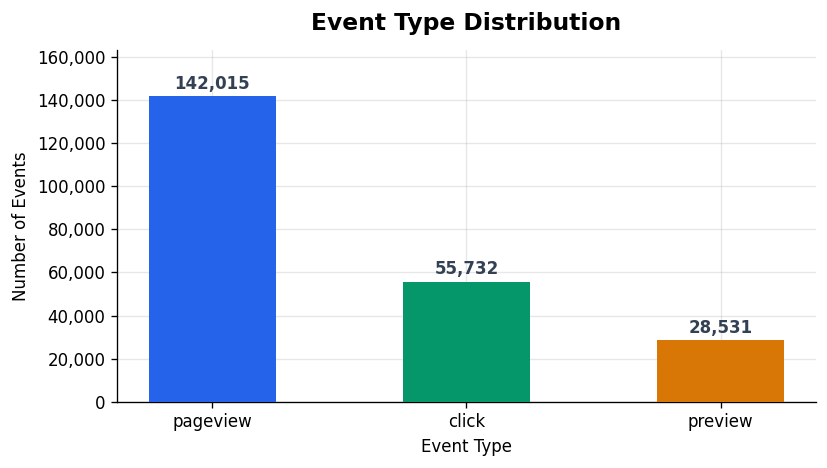

           count   pct
event                 
pageview  142015 62.76
click      55732 24.63
preview    28531 12.61


In [8]:
event_counts = df_clean['event'].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2563EB', '#059669', '#D97706']
bars = ax.bar(event_counts.index, event_counts.values, color=colors, width=0.5, zorder=3)

for bar, val in zip(bars, event_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
            f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#334155')

ax.set_title('Event Type Distribution', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Number of Events', fontsize=10)
ax.set_xlabel('Event Type', fontsize=10)
ax.set_ylim(0, event_counts.max() * 1.15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print(event_counts.to_frame('count').assign(pct=lambda d: (d['count']/total*100).round(2)))

## 8. Visualization 2 — Daily Traffic Trend (Line Chart)

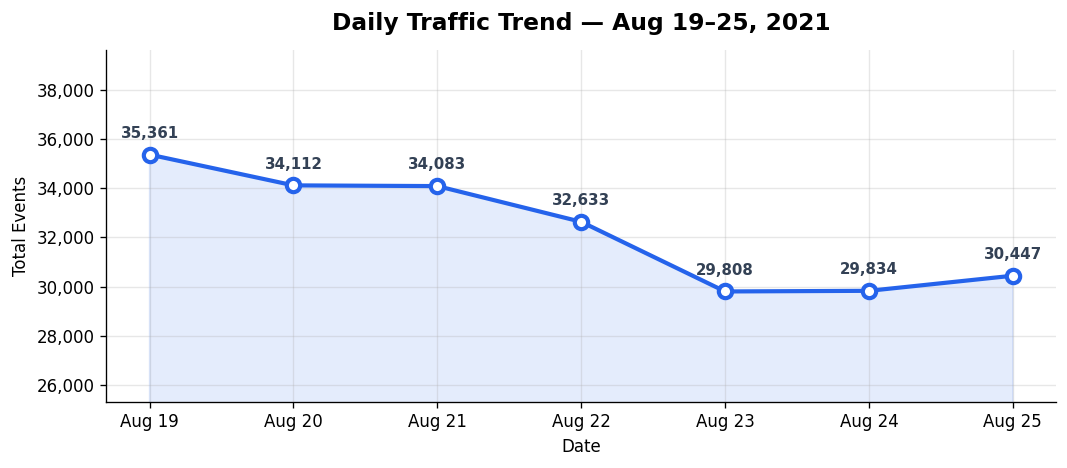

Peak day   : Aug 19 (35,361 events)
Lowest day : Aug 23 (29,808 events)
Drop       : 15.7%


In [9]:
daily = df_clean.groupby('day').size().reset_index(name='events')
daily['label'] = pd.to_datetime(daily['day']).dt.strftime('%b %d')

fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(daily['label'], daily['events'], alpha=0.12, color='#2563EB')
ax.plot(daily['label'], daily['events'],
        color='#2563EB', linewidth=2.5, marker='o',
        markersize=8, markerfacecolor='white', markeredgewidth=2.5, markeredgecolor='#2563EB',
        zorder=5)

for _, row in daily.iterrows():
    ax.annotate(f"{int(row['events']):,}",
                xy=(row['label'], row['events']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, color='#334155', fontweight='bold')

ax.set_title('Daily Traffic Trend — Aug 19–25, 2021', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Total Events', fontsize=10)
ax.set_xlabel('Date', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(daily['events'].min() * 0.85, daily['events'].max() * 1.12)
plt.tight_layout()
plt.show()

print(f"Peak day   : {daily.loc[daily['events'].idxmax(), 'label']} ({daily['events'].max():,} events)")
print(f"Lowest day : {daily.loc[daily['events'].idxmin(), 'label']} ({daily['events'].min():,} events)")
print(f"Drop       : {((daily['events'].max() - daily['events'].min()) / daily['events'].max() * 100):.1f}%")

## 9. Visualization 3 — Top 10 Countries (Horizontal Bar Chart)

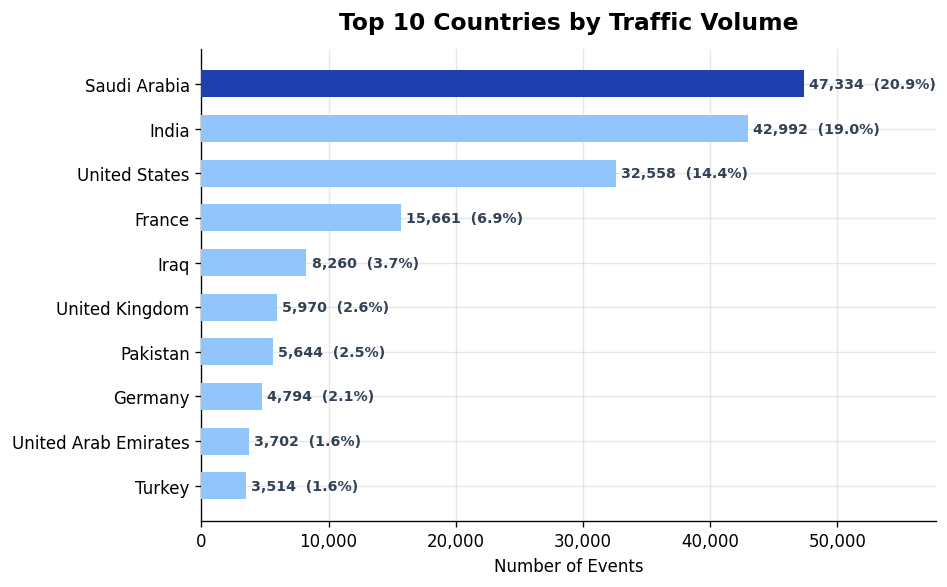

In [10]:
top_countries = df_clean['country'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(8, 5))
palette = ['#1E40AF'] + ['#93C5FD'] * 9
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1],
               color=palette[::-1], height=0.6, zorder=3)

for bar, val in zip(bars, top_countries.values[::-1]):
    ax.text(val + 400, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({val/total*100:.1f}%)',
            va='center', fontsize=8.5, color='#334155', fontweight='bold')

ax.set_title('Top 10 Countries by Traffic Volume', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Number of Events', fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, top_countries.max() * 1.22)
plt.tight_layout()
plt.show()

## 10. Visualization 4 — Event Share (Pie / Donut Chart)

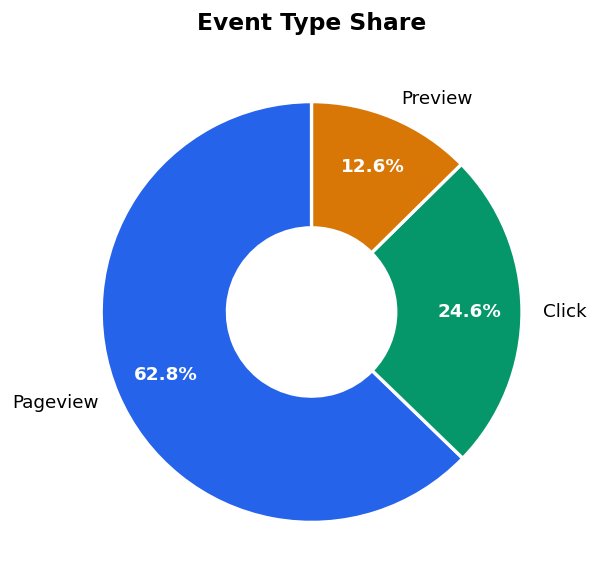

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
sizes  = [pageviews, clicks, previews]
labels = ['Pageview', 'Click', 'Preview']
clrs   = ['#2563EB', '#059669', '#D97706']

wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=clrs, autopct='%1.1f%%',
    startangle=90, wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2),
    pctdistance=0.75, textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')

ax.set_title('Event Type Share', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## 11. Visualization 5 — Top 10 Tracks (Bar Chart)

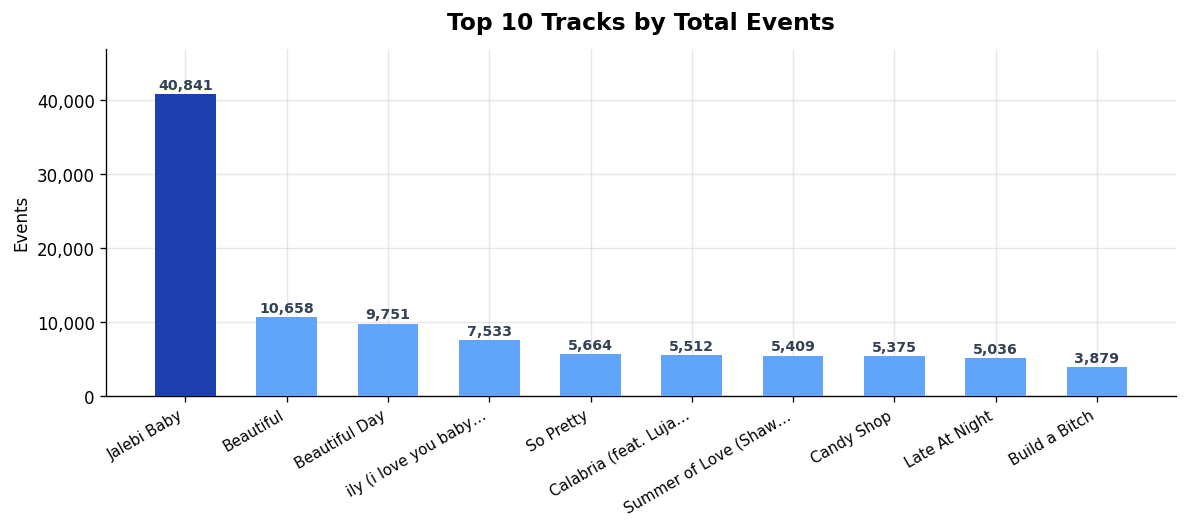

In [12]:
top_tracks = df_clean['track'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 4.5))
palette2 = ['#1E40AF'] + ['#60A5FA'] * 9
bars2 = ax.bar(range(len(top_tracks)), top_tracks.values, color=palette2, width=0.6, zorder=3)

for bar, val in zip(bars2, top_tracks.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{val:,}', ha='center', va='bottom', fontsize=8.5, fontweight='bold', color='#334155')

ax.set_xticks(range(len(top_tracks)))
ax.set_xticklabels([t[:20] + '…' if len(t) > 20 else t for t in top_tracks.index],
                   rotation=30, ha='right', fontsize=9)
ax.set_title('Top 10 Tracks by Total Events', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Events', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(0, top_tracks.max() * 1.15)
plt.tight_layout()
plt.show()

## 12. Visualization 6 — Event Type by Country (Stacked Bar)

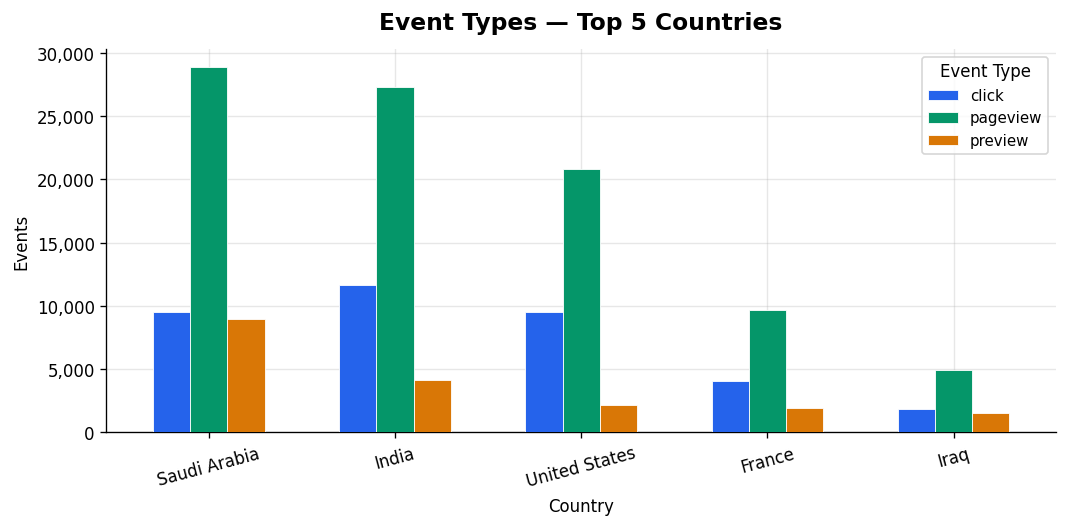

In [13]:
top5_countries = df_clean['country'].value_counts().head(5).index.tolist()
country_event = (df_clean[df_clean['country'].isin(top5_countries)]
                 .groupby(['country', 'event'])
                 .size().unstack(fill_value=0))
country_event = country_event.loc[top5_countries]

fig, ax = plt.subplots(figsize=(9, 4.5))
country_event.plot(kind='bar', ax=ax, color=['#2563EB','#059669','#D97706'],
                   width=0.6, zorder=3, edgecolor='white', linewidth=0.5)
ax.set_title('Event Types — Top 5 Countries', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Country', fontsize=10)
ax.set_ylabel('Events', fontsize=10)
ax.tick_params(axis='x', rotation=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Event Type', fontsize=9)
plt.tight_layout()
plt.show()

## 13. User Journey & Bounce-Rate Proxy

In [14]:
# Sessions approximated per linkid per day
sessions = df_clean.groupby(['linkid', 'day'])['event'].agg(list).reset_index()
sessions['has_click']   = sessions['event'].apply(lambda x: 'click' in x)
sessions['has_preview'] = sessions['event'].apply(lambda x: 'preview' in x)
sessions['bounced']     = sessions['event'].apply(lambda x: x == ['pageview'])

total_sessions = len(sessions)
converted      = sessions['has_click'].sum()
bounced        = sessions['bounced'].sum()
bounce_rate    = bounced / total_sessions * 100
conv_rate      = converted / total_sessions * 100

print("=" * 45)
print(f"  Approx. Sessions     : {total_sessions:>10,}")
print(f"  Sessions w/ Click    : {converted:>10,}  ({conv_rate:.1f}%)")
print(f"  Single-PV (bounced)  : {bounced:>10,}  ({bounce_rate:.1f}%)")
print("=" * 45)

  Approx. Sessions     :      6,563
  Sessions w/ Click    :      4,239  (64.6%)
  Single-PV (bounced)  :      1,793  (27.3%)


## 14. Top Entry Points (Most-Accessed Link IDs)

In [15]:
top_links = df_clean['linkid'].value_counts().head(10).reset_index()
top_links.columns = ['link_id', 'events']
top_links['track'] = top_links['link_id'].map(
    df_clean.groupby('linkid')['track'].first()
)
top_links['artist'] = top_links['link_id'].map(
    df_clean.groupby('linkid')['artist'].first()
)
top_links[['track','artist','events']]

,track,artist,events
0,Jalebi Baby,Tesher,40841
1,Beautiful,Anne-Marie,10314
2,Beautiful Day,Tundra Beats,9750
3,ily (i love you baby) (feat. Emilee),"Surf Mesa, Emilee",6733
4,Calabria (feat. Lujavo & Nito-Onna),"DMNDS, Strange Fruits Music, Fallen Roses, Luj...",5512
5,So Pretty,Reyanna Maria,5437
6,Candy Shop,"50 Cent, Olivia",5367
7,Summer of Love (Shawn Mendes & Tainy),"Shawn Mendes, Tainy",5352
8,Late At Night,Roddy Ricch,5036
9,Build a Bitch,Bella Poarch,3879


## 15. Missing Values Heatmap

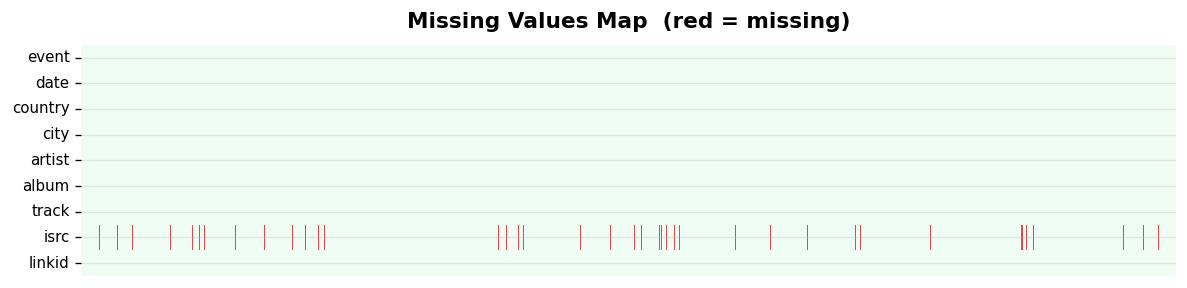

Missing value counts:
country      11
city         11
artist       37
album         7
track         5
isrc       7121
dtype: int64


In [16]:
fig, ax = plt.subplots(figsize=(10, 2.5))
missing_mask = df.isnull().T
sns.heatmap(missing_mask, cmap=['#F0FDF4','#EF4444'], cbar=False, ax=ax,
            linewidths=0, xticklabels=False)
ax.set_title('Missing Values Map  (red = missing)', fontsize=13, fontweight='bold', pad=10)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)
plt.tight_layout()
plt.show()

print("Missing value counts:")
print(df.isnull().sum()[df.isnull().sum() > 0])

## 16. Key Insights & Recommendations for Alfido Tech

### 📌 Insight 1 — MENA Region Dominates
- **Finding:** Saudi Arabia alone drives **20.9%** of all traffic; combined with Iraq and UAE, MENA represents **>25%** of sessions.
- **Action:** Build Arabic (RTL) landing pages and run MENA-targeted ad campaigns. Even a 10% conversion lift in this segment adds thousands of weekly clicks.

---

### 📌 Insight 2 — Preview → Click Drop-Off
- **Finding:** 28,531 previews (~12.6%) do not convert to clicks. This is a mid-funnel leak.
- **Action:** A/B test enriched preview cards (30-second audio snippets, artist bios, social proof). Target metric: **+5% preview-to-click rate**.

---

### 📌 Insight 3 — Mid-Week Traffic Dip
- **Finding:** Daily traffic drops ~16% from the Aug 19 peak to Aug 23 before recovering slightly.
- **Action:** Schedule content pushes, email campaigns, or playlist features on **Wednesday–Thursday** to smooth the curve.

---

### 📌 Insight 4 — Single-Track Concentration Risk
- **Finding:** "Jalebi Baby" alone accounts for **18.1%** of all events — nearly double the #2 track.
- **Action:** Diversify promoted playlists. Surface emerging artists (Anne-Marie, Tundra Beats) to reduce dependency on one viral track.

---

### 📌 Insight 5 — Fix ISRC Data Quality
- **Finding:** 7,121 rows (3.15%) are missing ISRC codes, preventing accurate royalty attribution.
- **Action:** Add an ingestion-layer validation rule requiring ISRC for every new content record.


## 17. Export Summary CSVs (Optional)

In [17]:
# Event summary
df_clean['event'].value_counts().to_csv('event_summary.csv')

# Country summary
df_clean['country'].value_counts().head(20).to_csv('country_summary.csv')

# Daily summary
daily.to_csv('daily_traffic.csv', index=False)

# Top tracks
df_clean['track'].value_counts().head(20).to_csv('top_tracks.csv')

print("✅ CSVs exported: event_summary, country_summary, daily_traffic, top_tracks")

✅ CSVs exported: event_summary, country_summary, daily_traffic, top_tracks
